# Pointwise Area Comparison: Control vs Glaucoma

Compare area between CONTROL and GLAUCOMA groups at **each time point** separately.

**Method:**
- Mann-Whitney U test at each time point
- Benjamini-Hochberg FDR correction for multiple comparisons

**Prerequisites:** Run `01_data_processing.ipynb` first to generate the data files.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from pathlib import Path

In [12]:
RESULTS_DIR = Path('./results')
FIGURES_DIR = Path('./figures')
FIGURES_DIR.mkdir(exist_ok=True)
ALPHA = 0.05

# Project-wide colors (match 02, 03, 13, 15): CONTROL=blue, GLAUCOMA=red
condition_colors = {'CONTROL': '#377EB8', 'GLAUCOMA': '#E41A1C'}
LABEL_MAP = {'CONTROL': 'control', 'GLAUCOMA': 'glaucoma'}


## Load Data

In [13]:
df = pd.read_csv(RESULTS_DIR / 'eye_liquid_spread_measurements.csv')

df_area = df[(df['condition'].notna()) & (df['area_cm2'].notna())].copy()

print(f"Loaded {len(df_area)} area measurements")
print(f"Time points: {df_area['time_sec'].nunique()}")
print(f"\nCases per condition:")
display(df_area.groupby('condition')['case'].nunique())

Loaded 934 area measurements
Time points: 41

Cases per condition:


condition
CONTROL      8
GLAUCOMA    15
Name: case, dtype: int64

## Pointwise Mann-Whitney U Tests

In [14]:
time_points = sorted(df_area['time_sec'].unique())

results = []

for t in time_points:
    control_area = df_area[(df_area['condition'] == 'CONTROL') & (df_area['time_sec'] == t)]['area_cm2'].values
    glaucoma_area = df_area[(df_area['condition'] == 'GLAUCOMA') & (df_area['time_sec'] == t)]['area_cm2'].values
    
    if len(control_area) < 2 or len(glaucoma_area) < 2:
        continue
    
    stat, pval = stats.mannwhitneyu(control_area, glaucoma_area, alternative='two-sided')
    
    results.append({
        'time_sec': t,
        'n_control': len(control_area),
        'n_glaucoma': len(glaucoma_area),
        'mean_control': control_area.mean(),
        'mean_glaucoma': glaucoma_area.mean(),
        'diff': glaucoma_area.mean() - control_area.mean(),
        'U_statistic': stat,
        'p_value': pval
    })

df_results = pd.DataFrame(results)
print(f"Performed {len(df_results)} tests (one per time point)")

Performed 41 tests (one per time point)


In [15]:
rejected, p_adjusted, _, _ = multipletests(df_results['p_value'], alpha=ALPHA, method='fdr_bh')

df_results['p_adjusted'] = p_adjusted
df_results['significant'] = rejected

print("Pointwise comparison results (with BH correction):")
display(df_results.round(4))

Pointwise comparison results (with BH correction):


,time_sec,n_control,n_glaucoma,mean_control,mean_glaucoma,diff,U_statistic,p_value,p_adjusted,significant
0,0.00,8,15,1.2803,0.9023,-0.3780,92.0,0.0401,0.0444,True
1,0.25,8,15,1.5916,1.1743,-0.4173,96.0,0.0194,0.0351,True
2,0.50,8,15,1.8508,1.4020,-0.4487,96.0,0.0194,0.0351,True
3,0.75,8,15,2.0544,1.5774,-0.4770,98.0,0.0130,0.0351,True
4,1.00,8,15,2.1875,1.7235,-0.4640,97.0,0.0159,0.0351,True
5,1.25,8,15,2.3191,1.8382,-0.4809,98.0,0.0130,0.0351,True
6,1.50,8,15,2.4066,1.9407,-0.4659,96.0,0.0194,0.0351,True
7,1.75,8,15,2.4670,2.0158,-0.4512,96.0,0.0194,0.0351,True
8,2.00,8,15,2.5531,2.1064,-0.4467,97.0,0.0159,0.0351,True
9,2.25,8,15,2.5853,2.1633,-0.4221,94.0,0.0282,0.0351,True


## Visualization

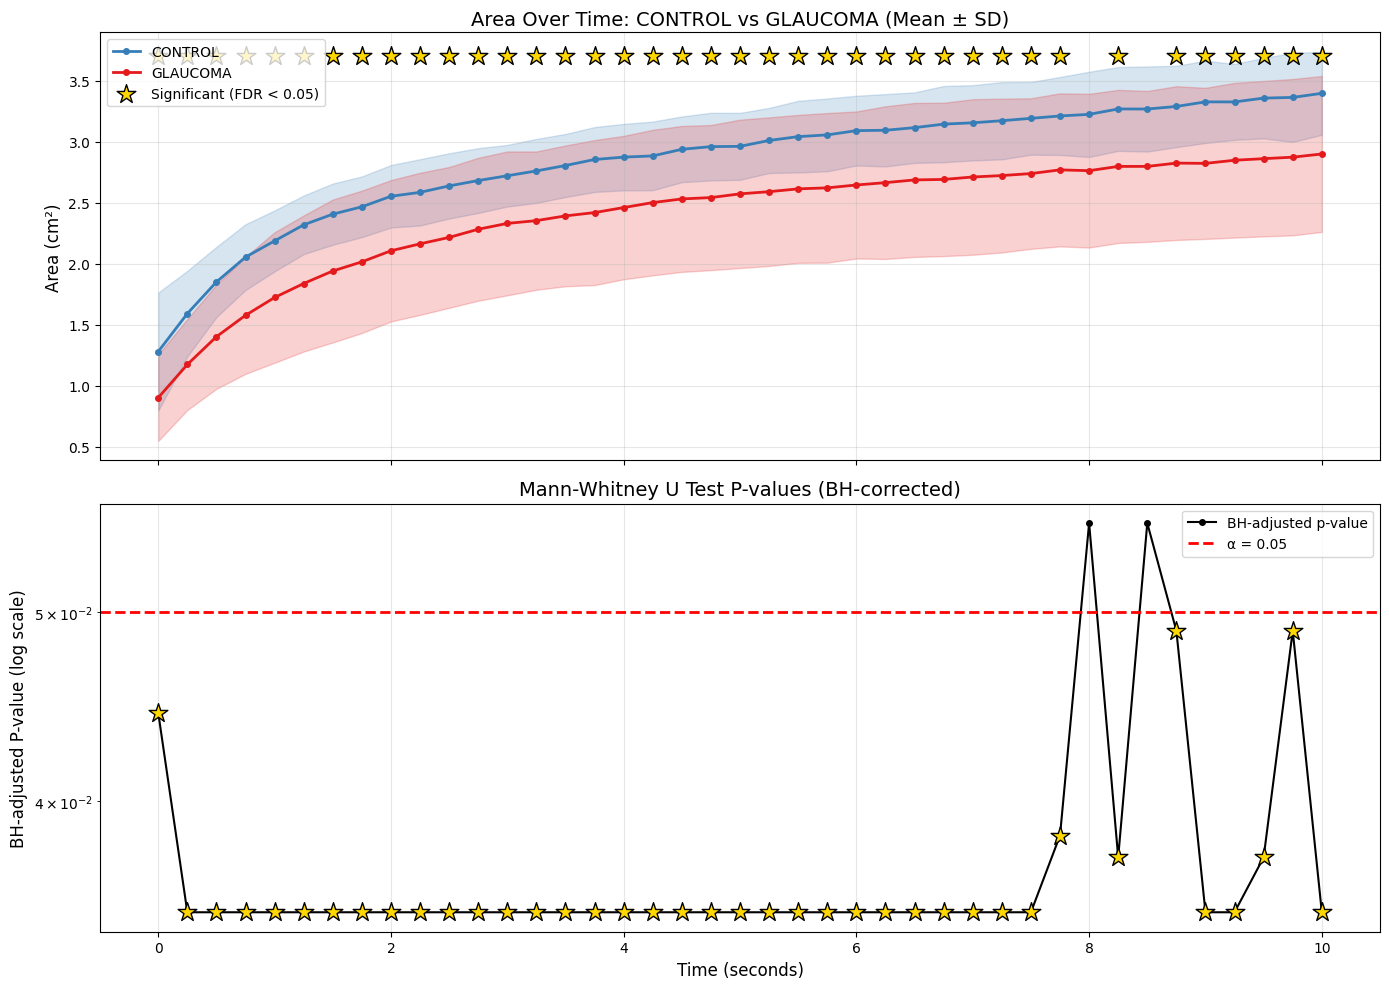

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
for condition in ['CONTROL', 'GLAUCOMA']:
    cond_data = df_area[df_area['condition'] == condition]
    stats_cond = cond_data.groupby('time_sec')['area_cm2'].agg(['mean', 'std'])
    
    ax.plot(stats_cond.index, stats_cond['mean'], 'o-', label=LABEL_MAP.get(condition, condition), 
            color=condition_colors[condition], markersize=4, linewidth=2)
    ax.fill_between(stats_cond.index, 
                    stats_cond['mean'] - stats_cond['std'], 
                    stats_cond['mean'] + stats_cond['std'], 
                    alpha=0.2, color=condition_colors[condition])

sig_times = df_results[df_results['significant']]['time_sec'].values
if len(sig_times) > 0:
    y_max = ax.get_ylim()[1]
    ax.scatter(sig_times, [y_max * 0.95] * len(sig_times), marker='*', s=200, 
               c='gold', edgecolors='black', zorder=5, label='Significant (FDR < 0.05)')

ax.set_ylabel('Area (cm²)', fontsize=12)
ax.set_title('Area Over Time: control vs glaucoma (Mean ± SD)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(df_results['time_sec'], df_results['p_adjusted'], 'ko-', markersize=4, label='BH-adjusted p-value')
ax.axhline(y=ALPHA, color='red', linestyle='--', linewidth=2, label=f'α = {ALPHA}')

if len(sig_times) > 0:
    sig_p = df_results[df_results['significant']]['p_adjusted'].values
    ax.scatter(sig_times, sig_p, marker='*', s=200, c='gold', edgecolors='black', zorder=5)

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('BH-adjusted P-value (log scale)', fontsize=12)
ax.set_title('Mann-Whitney U Test P-values (BH-corrected)', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '04a_area_over_time_mean_sd_pvalues.png', dpi=300, bbox_inches='tight')
plt.show()

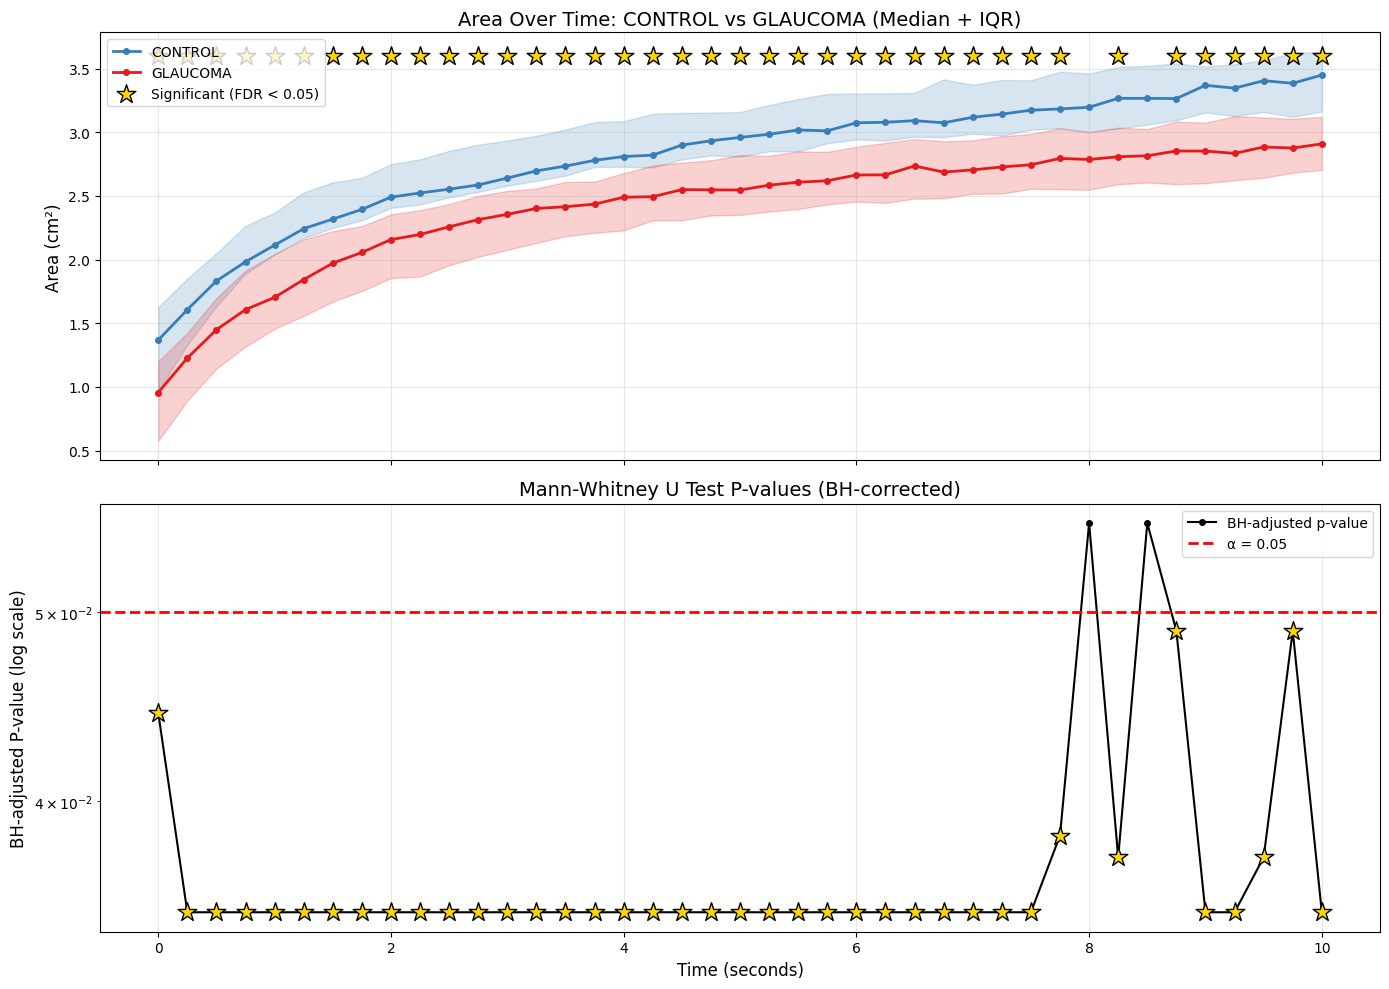

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
for condition in ['CONTROL', 'GLAUCOMA']:
    cond_data = df_area[df_area['condition'] == condition]
    stats_cond = cond_data.groupby('time_sec')['area_cm2'].agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    
    ax.plot(stats_cond.index, stats_cond['median'], 'o-', label=LABEL_MAP.get(condition, condition), 
            color=condition_colors[condition], markersize=4, linewidth=2)
    ax.fill_between(stats_cond.index, 
                    stats_cond['q25'], 
                    stats_cond['q75'], 
                    alpha=0.2, color=condition_colors[condition])

sig_times = df_results[df_results['significant']]['time_sec'].values
if len(sig_times) > 0:
    y_max = ax.get_ylim()[1]
    ax.scatter(sig_times, [y_max * 0.95] * len(sig_times), marker='*', s=200, 
               c='gold', edgecolors='black', zorder=5, label='significant (FDR < 0.05)')

ax.set_ylabel('Area (cm²)', fontsize=12)
ax.set_title('Area over time: control vs glaucoma (median + IQR)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(df_results['time_sec'], df_results['p_adjusted'], 'ko-', markersize=4, label='BH-adjusted p-value')
ax.axhline(y=ALPHA, color='red', linestyle='--', linewidth=2, label=f'α = {ALPHA}')

if len(sig_times) > 0:
    sig_p = df_results[df_results['significant']]['p_adjusted'].values
    ax.scatter(sig_times, sig_p, marker='*', s=200, c='gold', edgecolors='black', zorder=5)

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('BH-adjusted p-value (log scale)', fontsize=12)
ax.set_title('Mann-Whitney U test p-values (BH-corrected)', fontsize=14)
ax.axhline(y=ALPHA, color='red', linestyle='--', linewidth=2, label=f'α = {ALPHA}')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '04a_area_over_time_median_iqr_pvalues.png', dpi=300, bbox_inches='tight')
plt.show()

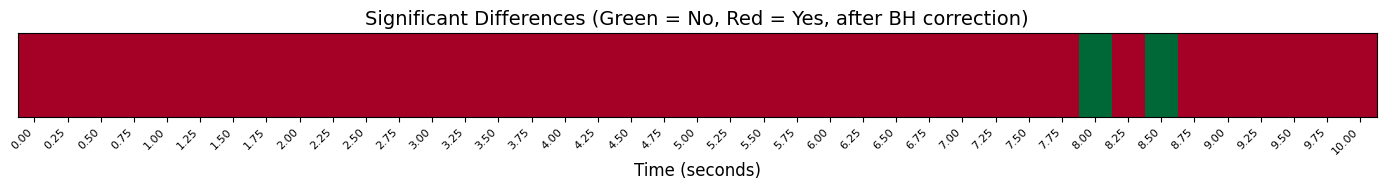

In [18]:
fig, ax = plt.subplots(figsize=(14, 2))

sig_array = df_results['significant'].values.reshape(1, -1).astype(int)
im = ax.imshow(sig_array, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)

ax.set_xticks(range(len(df_results)))
ax.set_xticklabels([f"{t:.2f}" for t in df_results['time_sec']], rotation=45, ha='right', fontsize=8)
ax.set_yticks([])
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_title('Significant Differences (Green = No, Red = Yes, after BH correction)', fontsize=14)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '04a_area_significance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Conclusions

In [19]:
print("="*70)
print("POINTWISE AREA COMPARISON: CONTROL vs GLAUCOMA")
print("="*70)

n_tests = len(df_results)
n_sig = df_results['significant'].sum()

print(f"\nTotal time points tested: {n_tests}")
print(f"Significant after BH correction: {n_sig} ({100*n_sig/n_tests:.1f}%)")

if n_sig > 0:
    print(f"\n" + "="*70)
    print("TIME POINTS WITH SIGNIFICANT AREA DIFFERENCES")
    print("="*70)
    
    sig_results = df_results[df_results['significant']].copy()
    
    for _, row in sig_results.iterrows():
        direction = "higher" if row['diff'] > 0 else "lower"
        print(f"\nt = {row['time_sec']:.2f} sec:")
        print(f"  CONTROL mean:  {row['mean_control']:.4f} cm\u00b2")
        print(f"  GLAUCOMA mean: {row['mean_glaucoma']:.4f} cm\u00b2")
        print(f"  Difference:    {row['diff']:.4f} cm\u00b2 (GLAUCOMA {direction})")
        print(f"  p-value (raw): {row['p_value']:.4f}")
        print(f"  p-value (BH):  {row['p_adjusted']:.4f} *")
    
    print(f"\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"\nGLAUCOMA shows significantly different area at {n_sig} of {n_tests} time points.")
    time_range = f"{sig_results['time_sec'].min():.2f}s - {sig_results['time_sec'].max():.2f}s"
    print(f"Significant time range: {time_range}")
    mean_diff = sig_results['diff'].mean()
    direction = 'larger' if mean_diff > 0 else 'smaller'
    print(f"Average area difference: {mean_diff:.4f} cm\u00b2 (GLAUCOMA {direction})")
else:
    print(f"\n" + "="*70)
    print("NO SIGNIFICANT DIFFERENCES FOUND")
    print("="*70)
    print(f"\nAfter Benjamini-Hochberg correction, no time points showed")
    print(f"significant area differences between CONTROL and GLAUCOMA.")
    min_p_row = df_results.loc[df_results['p_adjusted'].idxmin()]
    print(f"\nClosest to significance: t = {min_p_row['time_sec']:.2f}s (p_adj = {min_p_row['p_adjusted']:.4f})")

POINTWISE AREA COMPARISON: CONTROL vs GLAUCOMA

Total time points tested: 41
Significant after BH correction: 39 (95.1%)

TIME POINTS WITH SIGNIFICANT AREA DIFFERENCES

t = 0.00 sec:
  CONTROL mean:  1.2803 cm²
  GLAUCOMA mean: 0.9023 cm²
  Difference:    -0.3780 cm² (GLAUCOMA lower)
  p-value (raw): 0.0401
  p-value (BH):  0.0444 *

t = 0.25 sec:
  CONTROL mean:  1.5916 cm²
  GLAUCOMA mean: 1.1743 cm²
  Difference:    -0.4173 cm² (GLAUCOMA lower)
  p-value (raw): 0.0194
  p-value (BH):  0.0351 *

t = 0.50 sec:
  CONTROL mean:  1.8508 cm²
  GLAUCOMA mean: 1.4020 cm²
  Difference:    -0.4487 cm² (GLAUCOMA lower)
  p-value (raw): 0.0194
  p-value (BH):  0.0351 *

t = 0.75 sec:
  CONTROL mean:  2.0544 cm²
  GLAUCOMA mean: 1.5774 cm²
  Difference:    -0.4770 cm² (GLAUCOMA lower)
  p-value (raw): 0.0130
  p-value (BH):  0.0351 *

t = 1.00 sec:
  CONTROL mean:  2.1875 cm²
  GLAUCOMA mean: 1.7235 cm²
  Difference:    -0.4640 cm² (GLAUCOMA lower)
  p-value (raw): 0.0159
  p-value (BH):  0.0351

In [20]:
output_path = RESULTS_DIR / 'pointwise_area_control_vs_glaucoma.csv'
df_results.to_csv(output_path, index=False)
print(f"\nResults saved to: {output_path}")


Results saved to: results\pointwise_area_control_vs_glaucoma.csv
